MAX2769 filter specs
* 4 MHz center freq passband ()
    * 2.5, 4.2, 8 MHz 3dB bandwidths
* LPF
    * 9 MHz 3dB bandwidth
* Stopband attenuation
    * 3rd order, 2.5 MHz bandwidth, measured at 4 MHz - 30 dB
    * 5th order, .. - 41 min, 49.5 typ dB
  
Important specs: 5th order, 4 MHz IF, 2.5 MHz BW, what type?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# IIR Filter

This filter works but is frequency symmetric (ie, +- F_if are both passed).

In [3]:
order = 5
f_if = 4e6
f_s = 18e6
bw = 2.5e6

In [4]:
sos = signal.iirfilter(
    order,
    [f_if - bw/2, f_if + bw/2],
    btype="bandpass",
    ftype="butter",
    output="sos",
    fs=f_s,
)

/tmp/ipykernel_247/298991302.py:3: RuntimeWarning: divide by zero encountered in log10
  h2_iir = 20*np.log10(np.abs(h_iir))


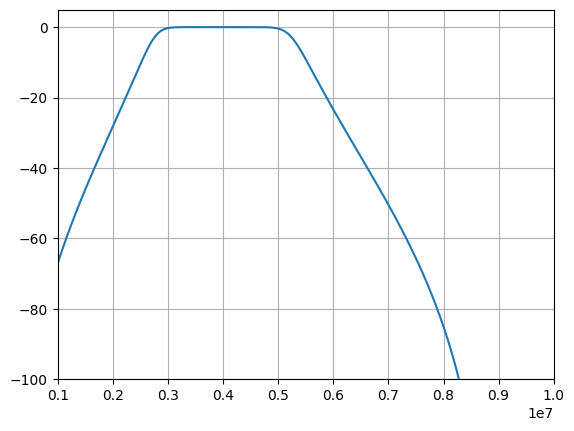

In [5]:
w_iir, h_iir = signal.sosfreqz(sos, 2000, fs=f_s)

h2_iir = 20*np.log10(np.abs(h_iir))

plt.plot(w_iir, h2_iir)
plt.xlim([1e6, 10e6])
plt.ylim([-100, 5])
plt.grid()

# FIR Filter

Attempt to get the same result as the IIR filter but only passing positive frequencies.

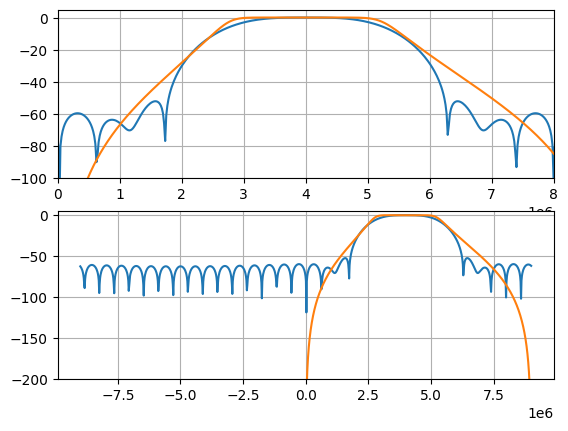

In [6]:
h = signal.firwin(31, bw/2, fs=f_s).astype(np.complex128)

t = np.arange(len(h)) / f_s
h = h * np.exp(2j*np.pi*t*f_if)

h_extended = np.zeros(2**10, dtype=np.complex128)
h_extended[0:len(h)] = h

H = np.fft.fftshift(np.fft.fft(h_extended))
w = np.linspace(-f_s/2, f_s/2, len(h_extended))

plt.subplot(2, 1, 1)
plt.plot(w, 20*np.log10(np.abs(H)))
plt.plot(w_iir, h2_iir)
plt.xlim([0, 8e6])
plt.ylim([-100, 5])
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(w, 20*np.log10(np.abs(H)))
plt.plot(w_iir, h2_iir)
# plt.xlim([0, 8e6])
plt.ylim([-200, 5])
plt.grid()